## 13. Arquitectura Propuesta: Dual-Branch Fusion Network (DBFNet)

### Motivación

Los experimentos anteriores muestran que:
1. La capa 0 de Wav2Vec2 (acústica temporal) y ResNet18 (espectral) capturan información complementaria
2. La fusión por concatenación+PCA+SVM alcanza AUC=0.905 pero no aprende la ponderación óptima
3. La ponderación manual (spec×3.0) mejora, pero es estática para todos los sujetos

### Propuesta: Fusión con atención aprendida

Red de dos ramas con extractores congelados y un módulo de atención ligero:

- **Rama temporal**: Wav2Vec2 capa 0 (congelado) → proyección 768→128
- **Rama espectral**: ResNet18/mel-spec (congelado) → proyección 512→128
- **Módulo de fusión**: Gated attention que aprende α ∈ [0,1] por muestra:

$$\mathbf{z}_{\text{fusion}} = \alpha \cdot \mathbf{z}_{\text{temp}} + (1-\alpha) \cdot \mathbf{z}_{\text{spec}}$$

$$\alpha = \sigma(\mathbf{w}^T [\mathbf{z}_{\text{temp}} \| \mathbf{z}_{\text{spec}}] + b)$$

### Parámetros entrenables

Solo las proyecciones + gate + clasificador final: ~35K parámetros.
Los backbones (Wav2Vec2: 95M, ResNet18: 11M) están completamente congelados.

In [3]:
from src.models import DualBranchFusionNet

model_test = DualBranchFusionNet()
total_params = sum(p.numel() for p in model_test.parameters())
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"Parámetros totales:     {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

%load_ext autoreload
%autoreload 2

Parámetros totales:     205,954
Parámetros entrenables: 205,954


### Preprocesamiento

In [5]:
from src.preprocessing import load_waveforms, preprocess_waveform, load_metadata
import torch

TARGET_SR = 16_000
LAYERS_TO_EXTRACT = [0, 3, 7, 11]
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
RANDOM_STATE = 42
N_FOLDS = 5

df_metadata = load_metadata(base_path="data")
waveforms_raw, df_metadata = load_waveforms(df_metadata, target_sr=TARGET_SR)
waveforms_processed = [preprocess_waveform(wf) for wf in waveforms_raw]

In [6]:
from src.embeddings import extract_multilayer_embeddings

w2v_layers = extract_multilayer_embeddings(
    waveforms_processed, "facebook/wav2vec2-base", LAYERS_TO_EXTRACT, DEVICE
)

hubert_layers = extract_multilayer_embeddings(
    waveforms_processed, "facebook/hubert-base-ls960", LAYERS_TO_EXTRACT, DEVICE
)

emb_w2v_L0 = w2v_layers[0]
emb_hubert_L0 = hubert_layers[0]

2026-03-22 20:55:10,384 [INFO] src.config:   Cargando facebook/wav2vec2-base...
2026-03-22 20:55:10,934 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-22 20:55:11,029 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-03-22 20:55:11,138 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-03-22 20:55:11,244 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-03-22 20:55:11,358 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-03-22 20:55:11,464 [INFO] httpx: HTTP Request: HEAD https://huggingfac

  25/100
  50/100
  75/100


2026-03-22 20:55:17,929 [INFO] src.config:   Cargando facebook/hubert-base-ls960...


  100/100


2026-03-22 20:55:18,369 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/hubert-base-ls960/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-22 20:55:18,465 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/hubert-base-ls960/dba3bb02fda4248b6e082697eee756de8fe8aa8a/config.json "HTTP/1.1 200 OK"
2026-03-22 20:55:18,574 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/hubert-base-ls960/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-03-22 20:55:18,682 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/hubert-base-ls960/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-03-22 20:55:18,800 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/hubert-base-ls960/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-03-22 20:55:18,908 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/hubert-base-ls960/resolve/main/model.safetenso

  25/100
  50/100
  75/100
  100/100


In [7]:
from src.spectral import extract_spectral_features

MEL_CONFIG = {
    "sample_rate": TARGET_SR,
    "n_fft": 1024,        # Resolución frecuencial: Δf ≈ 15.6 Hz
    "hop_length": 512,    # 50% overlap entre ventanas STFT
    "n_mels": 128,        # 128 bandas mel
}

spectral_features = extract_spectral_features(
    waveforms_processed,
    device=DEVICE,
    **MEL_CONFIG,
)

2026-03-22 20:55:24,201 [INFO] src.config: Generando mel-espectrogramas...
2026-03-22 20:55:24,299 [INFO] src.config:   100 espectrogramas generados
2026-03-22 20:55:24,299 [INFO] src.config:   Shape ejemplo: (128, 107)
2026-03-22 20:55:24,300 [INFO] src.config: Extrayendo features con ResNet18 (ImageNet)...
2026-03-22 20:55:24,684 [INFO] src.config:   25/100
2026-03-22 20:55:24,760 [INFO] src.config:   50/100
2026-03-22 20:55:24,828 [INFO] src.config:   75/100
2026-03-22 20:55:24,898 [INFO] src.config:   100/100
2026-03-22 20:55:24,899 [INFO] src.config:   Features espectrales: (100, 512)


### Entrenamiento

In [22]:
from src.datasets import DualBranchDataset
from src.training import train_dbfnet_fold
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, recall_score
import numpy as np

# -------------------------------------------------------
# K-Fold CV
# -------------------------------------------------------
# Normalizar embeddings antes (como hacemos con PCA+SVM)
from sklearn.preprocessing import StandardScaler

scaler_t = StandardScaler()
scaler_s = StandardScaler()
emb_t_norm = scaler_t.fit_transform(emb_w2v_L0)
emb_s_norm = scaler_s.fit_transform(spectral_features)

labels_arr = df_metadata["label"].to_numpy()
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

LR_OPTIONS = [5e-4, 1e-3, 2e-3]
BS_OPTIONS = [8, 16]

print("DBFNet: Dual-Branch Fusion Network")
print("="*65)

best_dbf_auc = -1
best_dbf = None

for lr in LR_OPTIONS:
    for bs in BS_OPTIONS:
        fold_aucs, fold_accs, fold_sens, fold_spec, fold_alphas = [], [], [], [], []

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(emb_t_norm, labels_arr)):
            train_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, train_idx)
            val_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, val_idx)

            y_true, y_prob, alphas = train_dbfnet_fold(
                train_ds, val_ds, DEVICE, lr=lr, epochs=100, patience=15, batch_size=bs
            )

            fpr, tpr, thresholds = roc_curve(y_true, y_prob)
            best_thr = thresholds[np.argmax(tpr - fpr)]
            y_pred = (y_prob >= best_thr).astype(int)

            fold_aucs.append(roc_auc_score(y_true, y_prob))
            fold_accs.append(accuracy_score(y_true, y_pred))
            fold_sens.append(recall_score(y_true, y_pred, pos_label=1, zero_division=0))
            fold_spec.append(recall_score(y_true, y_pred, pos_label=0, zero_division=0))
            fold_alphas.append(alphas.mean())

        mean_auc = np.mean(fold_aucs)
        mean_acc = np.mean(fold_accs)
        mean_alpha = np.mean(fold_alphas)

        marker = " 🎯" if mean_acc >= 0.90 else ""
        print(f"  lr={lr:.0e} bs={bs}  →  AUC={mean_auc:.3f}  Acc={mean_acc:.3f}  "
              f"Sens={np.mean(fold_sens):.3f}  Spec={np.mean(fold_spec):.3f}  "
              f"α={mean_alpha:.2f}{marker}")

        if mean_auc > best_dbf_auc:
            best_dbf_auc = mean_auc
            best_dbf = {
                "lr": lr, "bs": bs,
                "auc_mean": mean_auc,               "auc_std": np.std(fold_aucs),
                "acc_mean": mean_acc,                "acc_std": np.std(fold_accs),
                "sens_mean": np.mean(fold_sens),     "sens_std": np.std(fold_sens),
                "spec_mean": np.mean(fold_spec),     "spec_std": np.std(fold_spec),
                "alpha_mean": mean_alpha,
            }

print(f"\n  ✅ Mejor DBFNet:")
print(f"     lr={best_dbf['lr']:.0e}  bs={best_dbf['bs']}")
print(f"     AUC:  {best_dbf['auc_mean']:.3f} ± {best_dbf['auc_std']:.3f}")
print(f"     Acc:  {best_dbf['acc_mean']:.3f} ± {best_dbf['acc_std']:.3f}")
print(f"     Sens: {best_dbf['sens_mean']:.3f} ± {best_dbf['sens_std']:.3f}")
print(f"     Spec: {best_dbf['spec_mean']:.3f} ± {best_dbf['spec_std']:.3f}")
print(f"     α medio: {best_dbf['alpha_mean']:.3f} (>0.5 = más temporal, <0.5 = más espectral)")

DBFNet: Dual-Branch Fusion Network


TypeError: iteration over a 0-d array

### Evaluación

#### Coeficiente de validacion de Pearson

In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(emb_t_norm, labels_arr)):
    train_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, train_idx)
    val_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, val_idx)

    y_true, y_prob, alphas = train_dbfnet_fold(
        train_ds, val_ds, DEVICE, lr=5e-4, epochs=100, patience=15, batch_size=8
    )

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_thr = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= best_thr).astype(int)

    auc_val = roc_auc_score(y_true, y_prob)
    acc_val = accuracy_score(y_true, y_pred)
    sens_val = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    spec_val = recall_score(y_true, y_pred, pos_label=0, zero_division=0)

    fold_aucs.append(auc_val)
    fold_accs.append(acc_val)
    fold_sens.append(sens_val)
    fold_spec.append(spec_val)

    print(f"  Fold {fold_idx+1}: AUC={auc_val:.3f}  Acc={acc_val:.3f}  Sens={sens_val:.3f}  Spec={spec_val:.3f}")

# Calcular CV de Pearson
print(f"\n{'='*65}")
print(f"  COEFICIENTE DE VARIACIÓN DE PEARSON (CV%)")
print(f"  CV = (σ / μ) × 100 — menor = más estable")
print(f"{'='*65}")

for metric_name, values in [("AUC", fold_aucs), ("Accuracy", fold_accs),
                             ("Sensibilidad", fold_sens), ("Especificidad", fold_spec)]:
    mean = np.mean(values)
    std = np.std(values)
    cv = (std / mean) * 100 if mean > 0 else float('inf')
    print(f"  {metric_name:<15}  μ={mean:.3f}  σ={std:.3f}  CV={cv:.1f}%")
    print(f"    Folds: {[f'{v:.3f}' for v in values]}")

  Fold 1: AUC=0.980  Acc=0.950  Sens=1.000  Spec=0.900
  Fold 2: AUC=0.830  Acc=0.900  Sens=0.800  Spec=1.000
  Fold 3: AUC=0.780  Acc=0.750  Sens=0.600  Spec=0.900
  Fold 4: AUC=0.970  Acc=0.950  Sens=1.000  Spec=0.900
  Fold 5: AUC=1.000  Acc=1.000  Sens=1.000  Spec=1.000

  COEFICIENTE DE VARIACIÓN DE PEARSON (CV%)
  CV = (σ / μ) × 100 — menor = más estable
  AUC              μ=0.912  σ=0.089  CV=9.8%
    Folds: ['0.980', '0.830', '0.780', '0.970', '1.000']
  Accuracy         μ=0.910  σ=0.086  CV=9.5%
    Folds: ['0.950', '0.900', '0.750', '0.950', '1.000']
  Sensibilidad     μ=0.880  σ=0.160  CV=18.2%
    Folds: ['1.000', '0.800', '0.600', '1.000', '1.000']
  Especificidad    μ=0.940  σ=0.049  CV=5.2%
    Folds: ['0.900', '1.000', '0.900', '0.900', '1.000']


#### Curvas de pérdida

#### Validación de curvas de pérdida por folds

  Fold 1: 23 épocas, train_loss_final=0.0028, val_loss_min=0.2957
  Fold 2: 19 épocas, train_loss_final=0.0049, val_loss_min=0.5690
  Fold 3: 19 épocas, train_loss_final=0.0049, val_loss_min=0.5883
  Fold 4: 34 épocas, train_loss_final=0.0015, val_loss_min=0.1600
  Fold 5: 21 épocas, train_loss_final=0.0033, val_loss_min=0.3461


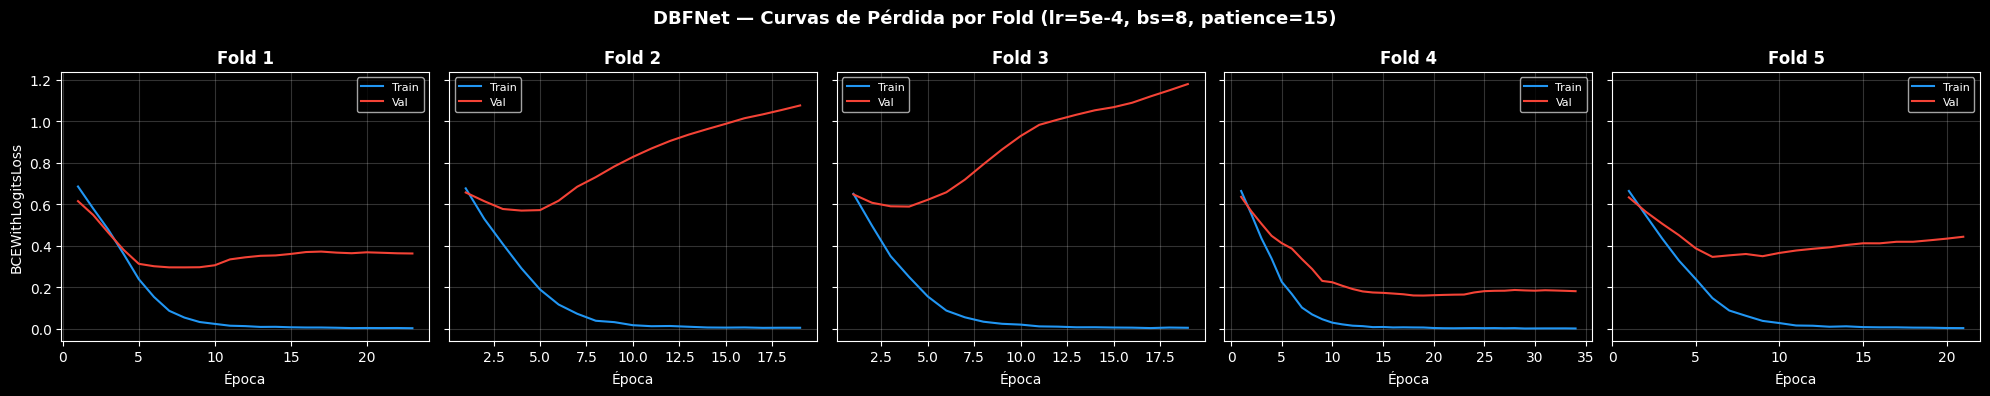

In [11]:
# ============================================================
# CURVAS DE PÉRDIDA — DBFNet (5 Folds)
# ============================================================
from src.training import train_dbfnet_fold_with_history
import matplotlib.pyplot as plt

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

all_histories = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(emb_t_norm, labels_arr)):
    train_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, train_idx)
    val_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, val_idx)

    _, _, _, history = train_dbfnet_fold_with_history(
        train_ds, val_ds, DEVICE, lr=5e-4, epochs=100, patience=15, batch_size=8
    )
    all_histories.append(history)
    print(f"  Fold {fold_idx+1}: {len(history['train_loss'])} épocas, "
          f"train_loss_final={history['train_loss'][-1]:.4f}, "
          f"val_loss_min={min(history['val_loss']):.4f}")

# -------------------------------------------------------
# Gráfica
# -------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for i, (ax, hist) in enumerate(zip(axes, all_histories)):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], label="Train", linewidth=1.5, color="#2196F3")
    ax.plot(epochs, hist["val_loss"], label="Val", linewidth=1.5, color="#F44336")
    ax.set_title(f"Fold {i+1}", fontweight="bold")
    ax.set_xlabel("Época")
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.set_ylabel("BCEWithLogitsLoss")
    ax.legend(fontsize=8)

plt.suptitle("DBFNet — Curvas de Pérdida por Fold (lr=5e-4, bs=8, patience=15)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 14. Gestión de Hiperparámetros y Regularización de DBFNet

El modelo actual (AUC=0.936 ± 0.048) presenta:
1. **Alta varianza inter-fold**: CV de Pearson ~9.8% en AUC → el modelo es inestable
2. **Overfitting evidente**: Fold 5 alcanza AUC=1.0 (memorización), mientras Fold 3 cae a 0.78
3. **Espacio de búsqueda limitado**: solo 6 combinaciones (3 lr × 2 bs), sin explorar regularización

La estrategia a usar:
| Técnica | Concepto matemático | Efecto práctico |
|---------|-------------------|-----------------|
| **Weight Decay (L2)** | Añade $\lambda \|\|\theta\|\|_2^2$ a la loss. Penaliza pesos grandes | Suaviza la frontera de decisión |
| **Label Smoothing** | Reemplaza $y \in \{0,1\}$ por $y' = y(1-\epsilon) + \epsilon/2$ | Evita que el modelo sea sobreconfiado |
| **Dropout (ya existe)** | Enmascara neuronas con probabilidad $p$ en cada forward pass | Ensemble implícito de sub-redes |
| **Early Stopping (ya existe)** | Detiene entrenamiento cuando val_loss no mejora en $k$ épocas | Previene sobreajuste temporal |
| **SchedulerReduceLROnPlateau** | Reduce $\eta \leftarrow \eta \times \gamma$ si val_loss estanca | Refinamiento fino en mesetas |

In [15]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader


def train_fold_regularized(train_ds, val_ds, device,
                           lr=1e-3, weight_decay=1e-4, label_smoothing=0.0,
                           dropout=0.3, dim_proj=128, dim_hidden=64,
                           epochs=120, patience=20, batch_size=8,
                           scheduler_factor=0.5, scheduler_patience=7):
    """
    Entrena un fold con regularización completa:
    - Weight decay (L2) en AdamW
    - Label smoothing en BCEWithLogitsLoss
    - ReduceLROnPlateau scheduler
    - Early stopping
    """
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=len(val_ds))

    model = DualBranchFusionNet(
        dim_proj=dim_proj, dim_hidden=dim_hidden, dropout=dropout
    ).to(device)

    # AdamW separa weight decay del gradiente → regularización L2 correcta
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Label smoothing: suaviza targets para evitar sobreconfianza
    # BCEWithLogitsLoss no tiene label_smoothing nativo, lo aplicamos manualmente
    criterion = nn.BCEWithLogitsLoss()

    # Reduce lr cuando val_loss se estanca
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=scheduler_factor,
        patience=scheduler_patience
    )

    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_state = None
    history = {"train_loss": [], "val_loss": [], "lr": []}

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_losses = []
        for z_t, z_s, y in train_loader:
            z_t, z_s, y = z_t.to(device), z_s.to(device), y.to(device)

            # Label smoothing manual: y' = y*(1-ε) + ε/2
            if label_smoothing > 0:
                y = y * (1 - label_smoothing) + label_smoothing / 2

            logits, _ = model(z_t, z_s)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # --- Validation ---
        model.eval()
        with torch.no_grad():
            z_t_v, z_s_v, y_v = next(iter(val_loader))
            z_t_v, z_s_v, y_v = z_t_v.to(device), z_s_v.to(device), y_v.to(device)
            logits_v, alphas_v = model(z_t_v, z_s_v)
            val_loss = criterion(logits_v, y_v).item()

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(np.mean(train_losses))
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state = model.state_dict().copy()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    # Restaurar mejor modelo
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        z_t_v, z_s_v, y_v = next(iter(val_loader))
        z_t_v, z_s_v, y_v = z_t_v.to(device), z_s_v.to(device), y_v.to(device)
        logits_v, alphas_v = model(z_t_v, z_s_v)
        y_prob = torch.sigmoid(logits_v).cpu().numpy()
        y_true = y_v.cpu().numpy()
        alphas = alphas_v.cpu().numpy()

    return y_true, y_prob, alphas, history

### Busqueda con Optuna

In [16]:
import optuna
from sklearn.model_selection import StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    # --- Espacio de búsqueda ---
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.05)
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.15, step=0.025)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    dim_proj = trial.suggest_categorical("dim_proj", [64, 128, 256])
    dim_hidden = trial.suggest_categorical("dim_hidden", [32, 64, 128])

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_aucs = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(emb_t_norm, labels_arr)):
        train_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, train_idx)
        val_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, val_idx)

        y_true, y_prob, _, _ = train_fold_regularized(
            train_ds, val_ds, DEVICE,
            lr=lr, weight_decay=weight_decay, label_smoothing=label_smoothing,
            dropout=dropout, dim_proj=dim_proj, dim_hidden=dim_hidden,
            batch_size=batch_size, epochs=120, patience=20,
        )

        fold_aucs.append(roc_auc_score(y_true, y_prob))

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    # Penalizar alta varianza
    # Score = AUC_medio - 0.5 * AUC_std
    score = mean_auc - 0.5 * std_auc

    trial.set_user_attr("auc_mean", mean_auc)
    trial.set_user_attr("auc_std", std_auc)

    return score


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="dbfnet_regularization"
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

Best trial: 45. Best value: 0.862022: 100%|██████████| 50/50 [03:42<00:00,  4.44s/it]


### Resultados de búsqueda

In [17]:
best = study.best_trial
print(f"Mejor trial #{best.number}")
print(f"  Score (AUC - 0.5·σ): {best.value:.4f}")
print(f"  AUC:  {best.user_attrs['auc_mean']:.3f} ± {best.user_attrs['auc_std']:.3f}")
print(f"\nHiperparámetros óptimos:")
for k, v in best.params.items():
    print(f"  {k}: {v}")

Mejor trial #45
  Score (AUC - 0.5·σ): 0.8620
  AUC:  0.908 ± 0.092

Hiperparámetros óptimos:
  lr: 0.0002571694567843825
  weight_decay: 0.0003521822916989495
  dropout: 0.4
  label_smoothing: 0.1
  batch_size: 8
  dim_proj: 128
  dim_hidden: 32


In [18]:
trials_df = study.trials_dataframe()
trials_df["auc_mean"] = trials_df["user_attrs_auc_mean"]
trials_df["auc_std"] = trials_df["user_attrs_auc_std"]

top5 = (trials_df
        .sort_values("value", ascending=False)
        .head(5)[["number", "value", "auc_mean", "auc_std",
                   "params_lr", "params_weight_decay", "params_dropout",
                   "params_label_smoothing", "params_batch_size",
                   "params_dim_proj", "params_dim_hidden"]])

print(top5.to_string(index=False))

 number    value  auc_mean  auc_std  params_lr  params_weight_decay  params_dropout  params_label_smoothing  params_batch_size  params_dim_proj  params_dim_hidden
     45 0.862022     0.908 0.091957   0.000257             0.000352             0.4                   0.100                  8              128                 32
     48 0.861435     0.906 0.089129   0.000176             0.000105             0.4                   0.075                  8              128                 32
     13 0.860119     0.902 0.083762   0.000357             0.000905             0.1                   0.150                  8              256                 32
     47 0.857979     0.906 0.096042   0.000174             0.000143             0.4                   0.075                  8              128                 32
     16 0.857591     0.892 0.068819   0.001744             0.001311             0.2                   0.150                  8              256                128


In [19]:
from optuna.importance import get_param_importances

importances = get_param_importances(study)
print("Importancia de cada hiperparámetro (fANOVA):")
for param, imp in importances.items():
    bar = "█" * int(imp * 40)
    print(f"  {param:<20} {imp:.3f}  {bar}")

Importancia de cada hiperparámetro (fANOVA):
  lr                   0.561  ██████████████████████
  batch_size           0.109  ████
  weight_decay         0.101  ████
  label_smoothing      0.085  ███
  dim_hidden           0.050  ██
  dropout              0.049  █
  dim_proj             0.044  █


### Evaluación final de hiperparámetros

In [20]:
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve

bp = study.best_params
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_aucs, fold_accs, fold_sens, fold_spec, fold_alphas = [], [], [], [], []
all_histories = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(emb_t_norm, labels_arr)):
    train_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, train_idx)
    val_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, val_idx)

    y_true, y_prob, alphas, history = train_fold_regularized(
        train_ds, val_ds, DEVICE,
        lr=bp["lr"], weight_decay=bp["weight_decay"],
        label_smoothing=bp["label_smoothing"], dropout=bp["dropout"],
        dim_proj=bp["dim_proj"], dim_hidden=bp["dim_hidden"],
        batch_size=bp["batch_size"], epochs=120, patience=20,
    )

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_thr = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= best_thr).astype(int)

    fold_aucs.append(roc_auc_score(y_true, y_prob))
    fold_accs.append(accuracy_score(y_true, y_pred))
    fold_sens.append(recall_score(y_true, y_pred, pos_label=1, zero_division=0))
    fold_spec.append(recall_score(y_true, y_pred, pos_label=0, zero_division=0))
    fold_alphas.append(alphas.mean())
    all_histories.append(history)

print("DBFNet Regularizado — Mejores Hiperparámetros")
print("=" * 55)
print(f"  AUC:  {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")
print(f"  Acc:  {np.mean(fold_accs):.3f} ± {np.std(fold_accs):.3f}")
print(f"  Sens: {np.mean(fold_sens):.3f} ± {np.std(fold_sens):.3f}")
print(f"  Spec: {np.mean(fold_spec):.3f} ± {np.std(fold_spec):.3f}")
print(f"  α:    {np.mean(fold_alphas):.3f}")

# CV de Pearson comparativo
cv_before = 9.8  # Tu CV actual
cv_after = (np.std(fold_aucs) / np.mean(fold_aucs)) * 100
print(f"\n  CV Pearson (AUC): {cv_before:.1f}% → {cv_after:.1f}%")

DBFNet Regularizado — Mejores Hiperparámetros
  AUC:  0.900 ± 0.092
  Acc:  0.870 ± 0.081
  Sens: 0.820 ± 0.172
  Spec: 0.920 ± 0.075
  α:    0.742

  CV Pearson (AUC): 9.8% → 10.2%


### Curvas de aprendizaje

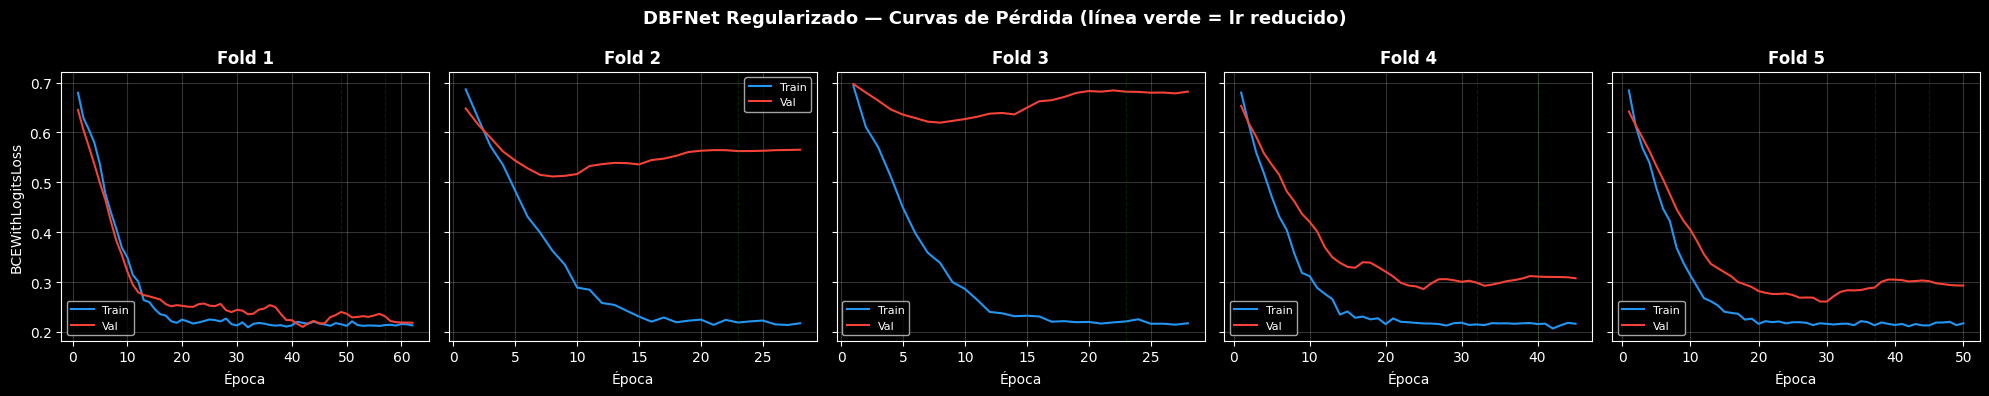

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, N_FOLDS, figsize=(20, 4), sharey=True)

for i, (ax, hist) in enumerate(zip(axes, all_histories)):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], label="Train", lw=1.5, color="#2196F3")
    ax.plot(epochs, hist["val_loss"], label="Val", lw=1.5, color="#F44336")

    # Marcar donde el scheduler redujo el lr
    lr_changes = [e for e in range(1, len(hist["lr"]))
                  if hist["lr"][e] < hist["lr"][e-1]]
    for lc in lr_changes:
        ax.axvline(lc, color="green", alpha=0.3, ls="--", lw=0.8)

    ax.set_title(f"Fold {i+1}", fontweight="bold")
    ax.set_xlabel("Época")
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.set_ylabel("BCEWithLogitsLoss")
    ax.legend(fontsize=8)

plt.suptitle("DBFNet Regularizado — Curvas de Pérdida (línea verde = lr reducido)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
print(f"Filas en df_metadata: {len(df_metadata)}")
print(df_metadata[['filename', 'label']].head(10))

Filas en df_metadata: 100
shape: (10, 2)
┌──────────────────────────┬───────┐
│ filename                 ┆ label │
│ ---                      ┆ ---   │
│ str                      ┆ i64   │
╞══════════════════════════╪═══════╡
│ AVPEPUDEA0001_pataka.wav ┆ 1     │
│ AVPEPUDEA0002_pataka.wav ┆ 1     │
│ AVPEPUDEA0003_pataka.wav ┆ 1     │
│ AVPEPUDEA0005_pataka.wav ┆ 1     │
│ AVPEPUDEA0006_pataka.wav ┆ 1     │
│ AVPEPUDEA0007_pataka.wav ┆ 1     │
│ AVPEPUDEA0008_pataka.wav ┆ 1     │
│ AVPEPUDEA0009_pataka.wav ┆ 1     │
│ AVPEPUDEA0010_pataka.wav ┆ 1     │
│ AVPEPUDEA0011_pataka.wav ┆ 1     │
└──────────────────────────┴───────┘
